# Data Walkthrough & Summary Statistics

This notebook is a guided tour of the four processed data files that feed the
whole replication pipeline, before any regression is run. For each file we
cover **where the data comes from**, **what we use it for** downstream, and
**summary statistics and a chart**.

| # | File | Frequency | Feeds |
|---|---|---|---|
| 1 | `fred_final_series_monthly.parquet` | Monthly | Figure I |
| 2 | `fred_final_series_annual.parquet` | Annual | Table I / II |
| 3 | `greenwood_hanson_hys.parquet` | Annual | Table II |
| 4 | `shiller_data_annual.parquet` | Annual | Table I / II |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "src"))
import summary_statistics as ss
from settings import config

PROCESSED_DATA_DIR = Path(config("PROCESSED_DATA_DIR"))
OUTPUT_DIR = Path(config("OUTPUT_DIR"))

data = ss.load_data()
for name, df in data.items():
    print(
        f"{name:>12}: {df.shape[0]:>5} rows x {df.shape[1]} cols, {df.index.min()} to {df.index.max()}"
    )

 fred_annual:    97 rows x 10 cols, 1929 to 2025
fred_monthly:  1212 rows x 6 cols, 1925-01-01 00:00:00 to 2025-12-01 00:00:00
         ghy:    97 rows x 3 cols, 1929 to 2025
     shiller:    97 rows x 5 cols, 1929-12-31 00:00:00 to 2025-12-31 00:00:00


## FRED Monthly Series

**Source:** [FRED](https://fred.stlouisfed.org/) (Federal Reserve Economic
Data), pulled via `pandas_datareader` in `pull_fred.py`,
then cleaned to a continuous monthly series by `process_fred_data_monthly.py`. 
The underlying FRED series are Moody's Seasoned
Baa/Aaa Corporate Bond Yield (`BAA`, `AAA`), a spliced long-term Treasury
yield (`GS10` plus two historical pre-1953 extensions), and the NBER
recession indicator (`USREC`).

**Used for:** this is the data behind **Figure I**, the paper's opening
exhibit — the Baa-Treasury credit spread, 1925-present. We use the Aaa-Treasury credit spread for the **Figure I** in the extension.

In [2]:
fred_monthly = data["fred_monthly"]
fred_monthly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1212 entries, 1925-01-01 to 2025-12-01
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   hist_recession_indicator  1212 non-null   int64  
 1   Treasury_10yr             1212 non-null   float64
 2   BAA                       1212 non-null   float64
 3   BAA_Treasury_spread       1212 non-null   float64
 4   AAA                       1212 non-null   float64
 5   AAA_Treasury_spread       1212 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 66.3 KB


### Summary Statistics

The Baa-Treasury spread averages just under 2
percentage points but has a fat right tail — the max exceeds 7pp — because
spreads spike (not fall) in stress episodes; that skew is exactly what
Figure I is built to show. The Aaa spread's minimum is slightly negative, a
reminder that "Aaa" and the 10-year Treasury aren't perfectly comparable at
every date. About a sixth of months in the sample are NBER recessions —
that's the shading used in the chart below.

In [3]:
ss.summary_dataframe(fred_monthly, ss.FRED_MONTHLY_SPECS).style.format(precision=2)

,Units,Mean,Std. Dev.,Min,Q1,Median,Q3,Max
Variable,,,,,,,,
Baa-Treasury spread,pp.,1.98,0.95,0.29,1.23,1.92,2.48,7.24
Aaa-Treasury spread,pp.,0.88,0.54,-0.17,0.39,0.81,1.23,2.68
Baa corporate bond yield,pct.,6.75,2.87,2.94,4.80,6.01,8.34,17.18
Aaa corporate bond yield,pct.,5.64,2.71,2.14,3.57,4.74,7.36,15.49
10-year Treasury yield,pct.,4.77,2.75,0.62,2.65,3.92,6.29,15.32
Months in NBER recession,pct. of months,16.58,37.21,0.00,0.00,0.00,0.00,100.00


### Featured Data Chart

Both spreads are plotted together, with NBER recessions shaded —
this is the raw material for Figure I in the paper. Every recession bar lines up with a
spread spike, and Baa is consistently wider than Aaa (the "quality gap" the
paper exploits): the two credit spreads move together, but not by the same
amount.

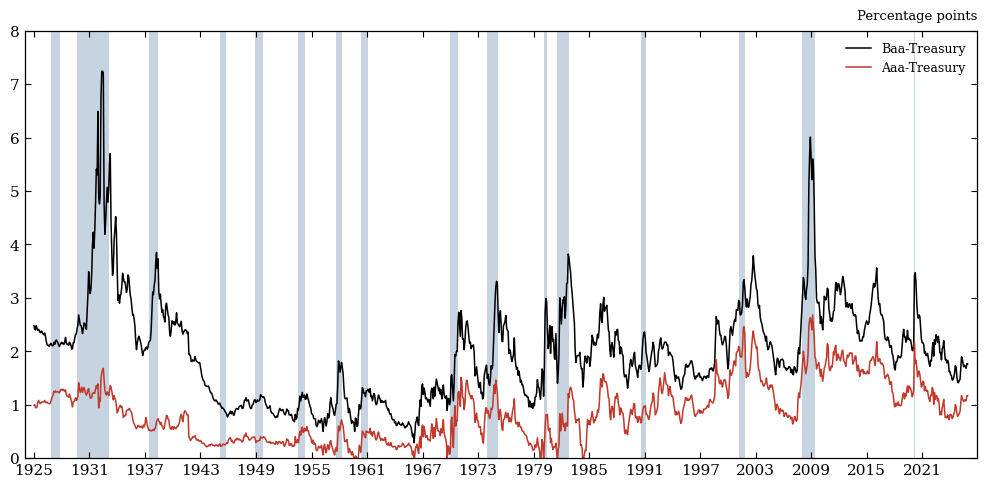

In [4]:
fig = ss.build_credit_spreads_figure(fred_monthly)
plt.show()

## FRED Annual Series

**Source:** the same FRED pull as above, aggregated to annual frequency by
`process_fred_data_annual.py`. Real GDP and population are built from FRED's
annual/quarterly series (`GDPCA`/`GDPC1`, `POPH`/`B230RC0Q173SBEA`); CPI
inflation is the December-to-December log change in `CPIAUCNS`; bond and
Treasury yields are December values of the monthly series from Section 1.

**Used for:** `GDP_per_capita` growth and the spreads are key **dependent variables**
throughout Tables I and II; the treasury yields and
inflation columns are the **control regressors** in Tables I and II.

In [5]:
fred_annual = data["fred_annual"]
fred_annual.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97 entries, 1929 to 2025
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GDP                  97 non-null     float64
 1   Population           97 non-null     float64
 2   GDP_per_capita       97 non-null     float64
 3   CPI_inflation        97 non-null     float64
 4   BAA                  97 non-null     float64
 5   AAA                  97 non-null     float64
 6   Treasury_10yr        97 non-null     float64
 7   Treasury_3mo         97 non-null     float64
 8   BAA_Treasury_spread  97 non-null     float64
 9   AAA_Treasury_spread  97 non-null     float64
dtypes: float64(10)
memory usage: 8.0 KB


### Summary Statistics

Real GDP per capita ranges from about \$7,000 to
\$69,000 over the sample — a century of growth compressed
into one column. The wide gap between each yield/spread row's mean and its
quartiles echoes the same right-skew seen in the monthly spreads above: most
years look "normal," and a handful of stress years pull the mean and max
well above the median.

In [6]:
ss.summary_dataframe(fred_annual, ss.FRED_ANNUAL_SPECS).style.format(precision=2)

,Units,Mean,Std. Dev.,Min,Q1,Median,Q3,Max
Variable,,,,,,,,
Real GDP,$tn,8.68,6.72,0.88,2.88,6.68,14.23,23.85
Population,millions,223.72,69.56,121.72,159.57,220.29,285.23,341.94
Real GDP per capita,$000s,33.30,18.08,6.99,18.14,30.34,49.92,69.75
CPI inflation (Dec/Dec),pct.,3.03,3.77,-10.84,1.49,2.71,4.00,16.66
Baa corporate bond yield,pct.,6.82,2.92,3.10,4.81,6.15,8.43,16.55
Aaa corporate bond yield,pct.,5.65,2.72,2.26,3.51,4.74,7.25,14.23
10-year Treasury yield,pct.,4.77,2.72,0.93,2.51,4.03,6.30,13.72
3-month Treasury yield,pct.,3.46,3.20,0.01,0.39,3.06,5.28,16.35
Baa-Treasury spread,pp.,2.05,1.06,0.40,1.26,1.92,2.56,6.49


### Featured Data Chart

We plot *growth* in real GDP per capita rather than the level,
since growth is what the regressions target. One thing stands out immediately: growth
was an order of magnitude more volatile before ~1950 (Great Depression,
WWII) than after. That is worth remembering
when interpreting any regression coefficient that treats every year the
same way.

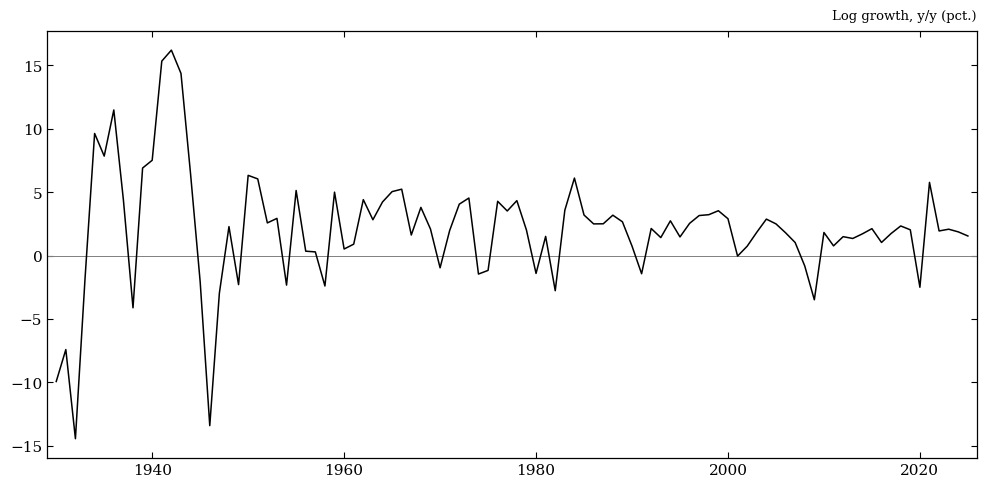

In [7]:
fig = ss.build_gdp_growth_figure(fred_annual)
plt.show()

## Greenwood-Hanson High-Yield Share

**Source:** two different sources, spliced together in
`pull_greenwood_hanson.py`:

- **1926–2008:** the published series from Greenwood & Hanson (2013),
  "Issuer Quality and Corporate Bond Returns," *Review of Financial
  Studies* 26(6), hand-transcribed from printed sources (Hickman 1960;
  Atkinson 1967; Moody's Bond Surveys).
- **2009–present:** reconstructed from Mergent FISD bond-level issuance
  and ratings data via WRDS, since the published series stops in 2008.

**Used for:** `ln_hy_share` is one of two "sentiment" ingredients in
Table II's first-stage regression — the idea being that a high share of
low-grade issuance signals investors reaching for yield, i.e. credit-market
froth.

In [8]:
ghy = data["ghy"]
print(ghy["source"].value_counts())

source
gh2013    80
fisd      17
Name: count, dtype: int64


In [9]:
ghy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97 entries, 1929 to 2025
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hy_share     97 non-null     float64
 1   ln_hy_share  96 non-null     float64
 2   source       97 non-null     object 
dtypes: float64(2), object(1)
memory usage: 2.7+ KB


### Summary Statistics

The mean/std/quantiles above describe `hy_share` and
`ln_hy_share` as if they were one continuous series — but the source counts
printed above show they're not: most of the sample uses the original
published series, and a meaningfully-sized, more recent chunk is a different
reconstruction. That split is invisible in a table of moments alone, which
is exactly why the chart below colors the two segments separately.

In [10]:
ss.summary_dataframe(ghy, ss.GHY_SPECS).style.format(precision=2)

,Units,Mean,Std. Dev.,Min,Q1,Median,Q3,Max
Variable,,,,,,,,
High-yield issuance share,pct.,19.48,15.08,0.00,6.23,14.98,29.41,63.93
Log high-yield share,log,-2.06,1.13,-6.02,-2.69,-1.89,-1.22,-0.45


### Featured Data Chart

Coloring by source makes the 2008/2009 splice visible directly on
the time series. Levels and volatility look broadly similar across the
splice, but the two segments are not measuring issuance quality with
identical methodology — worth flagging before treating this as one seamless
variable in a regression that spans both eras.

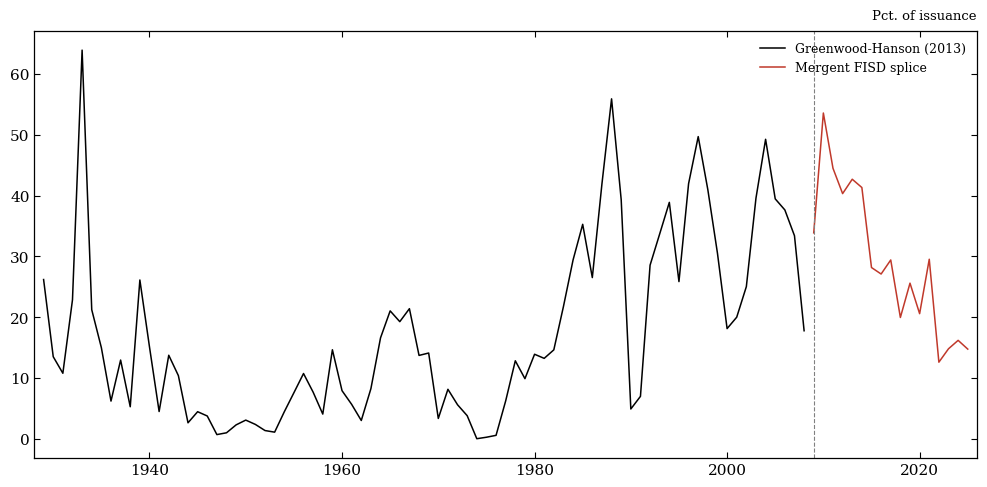

In [11]:
fig = ss.build_hy_share_figure(ghy)
plt.show()

## Shiller Annual Series

**Source:** Robert Shiller's [stock market data
website](https://shillerdata.com/) (`ie_data.xls`), pulled monthly by
`pull_shiller.py` and collapsed to annual (December) values in the same script.

**Used for:** `sp500_price` and `dividend` build the S&P 500 total log
return (`sp_return`, via `helper_functions.log_total_return`), the equity-return
regressor in Table I columns (2) and (3); `ln_pe10` (the log of Shiller's
cyclically adjusted P/E, or CAPE) is the second "sentiment" ingredient in
Table II's first stage, alongside `ln_hy_share` above. `ln_pe10` still lives
in the underlying data and feeds that regression — we just don't show it as
its own row below, since it carries the same information as `pe10`, only
log-transformed.

In [12]:
shiller = data["shiller"]
shiller.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 97 entries, 1929-12-31 to 2025-12-31
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sp500_price  97 non-null     float64
 1   dividend     97 non-null     float64
 2   pe10         97 non-null     float64
 3   ln_pe10      97 non-null     float64
 4   sp_return    96 non-null     float64
dtypes: float64(5)
memory usage: 4.5 KB


### Summary Statistics

CAPE ranges from under 8 to over 44 across the
sample, but its interquartile range is much narrower (roughly 12 to 25) — so
both the 2000 dot-com peak and the Depression-era trough sit well outside
what a "typical" year looks like. The S&P price and dividend rows show the
same order-of-magnitude skew for the same reason: a nominal price index
compounding over a century is nowhere close to normally distributed. The
added `sp_return` row is the annual log total return implied by
`sp500_price` and `dividend`: it averages a bit under 10% but swings from
-52% (1931) to +42% (1933), the same Depression-era years driving CAPE's
extremes above.

In [13]:
ss.summary_dataframe(shiller, ss.SHILLER_SPECS).style.format(precision=2)

,Units,Mean,Std. Dev.,Min,Q1,Median,Q3,Max
Variable,,,,,,,,
S&P Composite price index,index level,758.66,1318.14,6.82,26.04,106.50,1110.38,6853.03
S&P Composite dividend,$ per share,13.83,19.10,0.44,1.47,4.67,16.27,79.52
Cyclically adj. P/E (CAPE),ratio,19.23,8.48,7.83,11.75,17.56,24.86,44.20
S&P total return (log),pct.,9.54,18.06,-51.58,0.23,14.26,21.11,42.29


### Featured Data Chart

This chart pairs CAPE at
year $t$ with the cumulative S&P total return realized over the *following*
10 years. The relationship is strongly negative (corr.
≈ -0.67, fitted line shown in red): years that started out expensive
(CAPE above ~30, e.g. 1999-2000) were followed by materially weaker
decade-ahead returns than years that started out cheap (CAPE below ~10,
e.g. 1931-32 or 1980-82). That mean-reversion pattern is exactly why
`ln_pe10` earns a spot as a "sentiment" regressor in Table II's first
stage — it isn't just a valuation ratio, it's a genuine predictor of what
happens next.

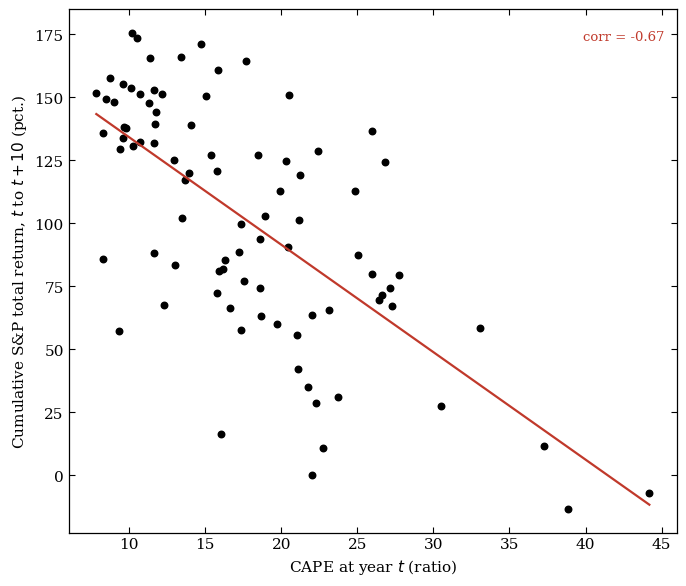

In [14]:
fig = ss.build_cape_figure(shiller)
plt.show()